# 14. K-Nearest Neighbors (KNN) and Support Vector Machines (SVM)


## Part 1: K-Nearest Neighbors (KNN)

### 1. Definition (What is KNN?)
**K-Nearest Neighbors (KNN)** is a simple, supervised machine learning algorithm that can be used to solve both classification and regression problems. It assumes that similar things exist in close proximity. In other words, similar data points are near each other.

### 2. Why use KNN?
* **Simple and Intuitive:** The math behind it is very easy to understand.
* **No Training Period (Lazy Learner):** KNN doesn't learn a discriminative function from the training data but memorizes the training dataset instead.
* **Versatile:** Can be used for classification, regression, and even search (like recommender systems).

### 3. How does KNN work? (In-Depth Theory)

The core concept of KNN relies on **distance metrics**.

**Step 1:** Select the number $K$ of the neighbors.
**Step 2:** Calculate the distance between the new/test data point and all training data points.
Common Distance Metrics:
* **Euclidean Distance:** The straight-line distance. $d = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$
* **Manhattan Distance:** The sum of absolute differences. $d = \sum_{i=1}^{n} |x_i - y_i|$

**Step 3:** Take the $K$ nearest neighbors as per the calculated distance.
**Step 4:** Among these $K$ neighbors, count the number of data points in each category.
**Step 5:** Assign the new data point to the category where the count is maximum.

---

### 4. Application Examples of KNN
1. **Recommender Systems:** If user A and user B buy similar products, they are 'neighbors'. We can recommend user A's purchases to user B.
2. **Handwriting Detection:** Comparing a written digit against a database of known digits.
3. **Healthcare:** Predicting whether a patient has a disease based on clinical records of patients with similar symptoms.

### 5. Implementation of KNN in Python
Let's apply KNN to a visual synthetic dataset.

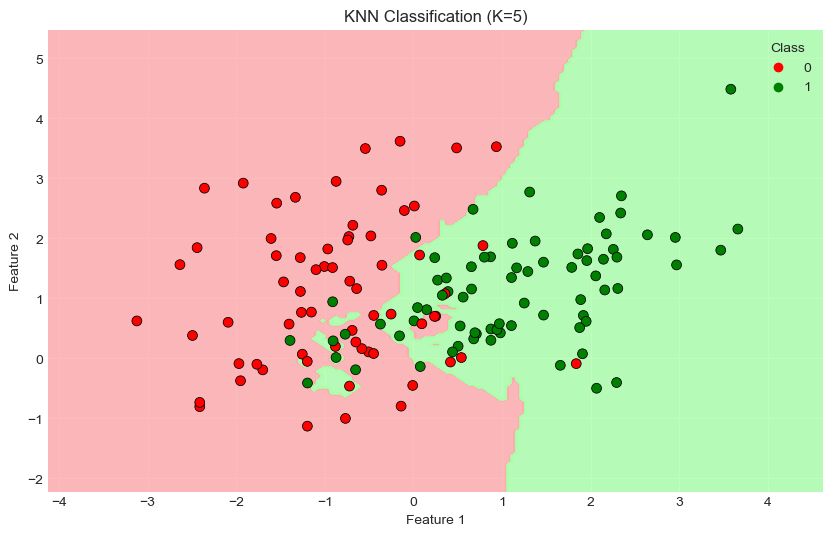

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

# Setup styling
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Generate synthetic data
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, 
                           n_clusters_per_class=1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train KNN
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# 3. Create a meshgrid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plotting
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ['red', 'green']

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, palette=cmap_bold, edgecolor="k", s=50)

plt.title(f"KNN Classification (K={k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title='Class')
plt.show()

---

## Part 2: Support Vector Machines (SVM)

### 1. Definition (What is SVM?)
**Support Vector Machine (SVM)** is a powerful and versatile supervised machine learning model, capable of performing linear or nonlinear classification, regression, and even outlier detection. Its core objective is to find a **hyperplane** in an N-dimensional space that distinctly classifies the data points.

### 2. Why use SVM?
* **Effective in High Dimensions:** Very effective when the number of features is greater than the number of samples.
* **Memory Efficient:** It uses a subset of training points in the decision function (called **support vectors**).
* **Versatile (The Kernel Trick):** It can efficiently perform non-linear classification using different kernel functions.

### 3. How does SVM work? (In-Depth Theory)

**The Hyperplane and the Margin**
Imagine a 2D space where your classes are linearly separable by a straight line. SVM doesn't just find *any* line; it finds the line that has the **maximum margin** (distance) between the data points of both classes.

* **Hyperplane:** The decision boundary. In 2D, it's a line. In 3D, it's a plane.
* **Support Vectors:** The data points that are closest to the hyperplane. These are the critical elements; modifying them will change the position of the hyperplane.
* **Margin:** The distance between the hyperplane and the nearest data point from either set. SVM aims to maximize this margin.

**The Mathematics of Margin**
The hyperplane is defined as: $w^T x + b = 0$
The distance from a point $x_i$ to the hyperplane is $\frac{|w^T x_i + b|}{||w||}$.
By setting the margins to $w^T x + b = 1$ and $w^T x + b = -1$, the total width of the margin becomes $\frac{2}{||w||}$. Minimizing $||w||$ maximizes the margin!

---

### 4. Application Examples of SVM
1. **Face Detection:** Identifying image boundaries and classifying them as face or non-face.
2. **Text and Hypertext Categorization:** Used for spam filtering, sentiment analysis, due to its effectiveness in high dimensional spaces (word vectors).
3. **Bioinformatics:** Protein classification and cancer classification based on gene expressions.

### 5. Implementation of SVM with the Kernel Trick
Let's see the magic of the **RBF (Radial Basis Function) Kernel** on a dataset that cannot be linearly separated (Concentric Circles).

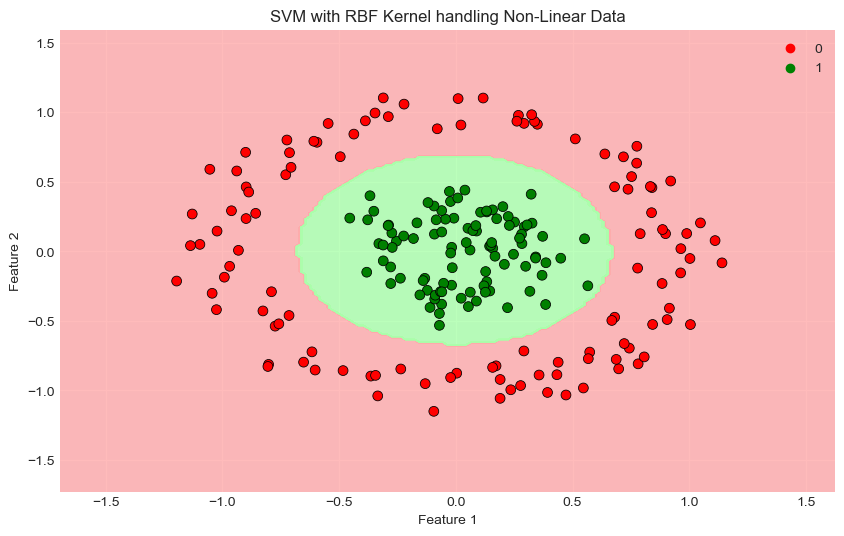

In [2]:
from sklearn.datasets import make_circles
from sklearn.svm import SVC

# 1. Generate Non-Linear Data (Circles)
X_circles, y_circles = make_circles(n_samples=300, factor=0.3, noise=0.1, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circles, y_circles, test_size=0.3, random_state=42)

# 2. Train SVM with RBF Kernel (Non-linear)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='auto')
svm_rbf.fit(X_train_c, y_train_c)

# 3. Create meshgrid for plotting
x_min, x_max = X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5
y_min, y_max = X_circles[:, 1].min() - 0.5, X_circles[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z_svm = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_svm, cmap=ListedColormap(['#FFAAAA', '#AAFFAA']), alpha=0.8)
sns.scatterplot(x=X_train_c[:, 0], y=X_train_c[:, 1], hue=y_train_c, palette=['red', 'green'], edgecolor="k", s=50)

plt.title("SVM with RBF Kernel handling Non-Linear Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

**Observation:** A straight line couldn't separate the inner green circle from the outer red circle. The RBF kernel implicitly maps the points into higher dimensions where a plane *can* slice the top off the 'mountain' of data, resulting in a circular decision boundary back in 2D space!

---
## Part 3: End-to-End Example (Breast Cancer Dataset)

Let's load a real-world dataset (Breast Cancer classification) and apply both KNN and SVM to compare their performance. This covers the full pipeline:
1. **Data Loading & Exploration**
2. **Data Preprocessing (Scaling)**
3. **Model Training (Fit)**
4. **Predictions**
5. **Evaluation Metrics**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Data Loading
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Dataset Shape: {X.shape}")
print(f"Target distribution:\n{pd.Series(y).value_counts(normalize=True).round(3)}")
X.head()

Dataset Shape: (569, 30)
Target distribution:
1    0.627
0    0.373
dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# 2. Data Preprocessing
# Split the data into train and test sets (80% train, 20% test)
# stratify=y ensures the same class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Distance-based algorithms (KNN & SVM) require feature scaling!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

--- KNN Results ---
Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



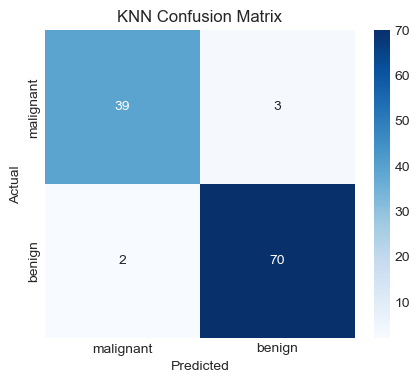

In [5]:
# 3. Model Training & Validation (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# 4. Predictions (KNN)
knn_preds = knn_model.predict(X_test_scaled)

# 5. Metrics (KNN)
print("--- KNN Results ---")
print(f"Accuracy: {accuracy_score(y_test, knn_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, knn_preds, target_names=data.target_names))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, knn_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- SVM Results ---
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



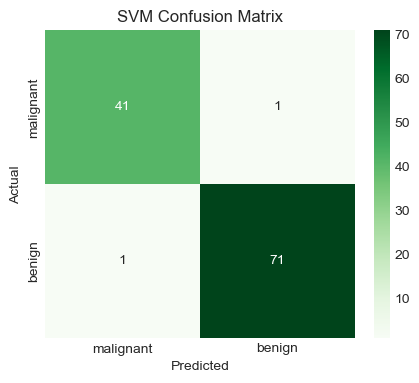

In [6]:
# 6. Model Training & Validation (SVM)
# Using SVM with an RBF kernel (Soft Margin is implied by default C=1.0)
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 7. Predictions (SVM)
svm_preds = svm_model.predict(X_test_scaled)

# 8. Metrics (SVM)
print("--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_preds, target_names=data.target_names))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, svm_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()